# 05 — Enrichissement INSEE

Croisement des données CNAV avec les séries macroéconomiques et démographiques INSEE.

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from src.visualize import save_fig
%matplotlib inline

EXT = '../data/raw/external/'
PRO = '../data/processed/'

# ── Chargement INSEE ──────────────────────────────────────────────────────────
ipc          = pd.read_parquet(EXT + 'insee_inflation.parquet').rename(columns={'valeur': 'ipc'})
chomage_sen  = pd.read_parquet(EXT + 'insee_chomage_seniors.parquet').rename(columns={'valeur': 'chomage_seniors_pct'})
chomage_ens  = pd.read_parquet(EXT + 'insee_chomage_ensemble.parquet').rename(columns={'valeur': 'chomage_ensemble_pct'})
mortalite    = pd.read_parquet(EXT + 'insee_mortalite.parquet').rename(columns={'valeur': 'taux_mortalite'})
natalite     = pd.read_parquet(EXT + 'insee_natalite.parquet').rename(columns={'valeur': 'naissances_moy_mensuel'})
population   = pd.read_parquet(EXT + 'insee_population.parquet').rename(columns={'valeur': 'population_milliers'})

# Naissances annuelles = moyenne mensuelle × 12
natalite['naissances_annuelles'] = (natalite['naissances_moy_mensuel'] * 12).round(0)

# ── Chargement CNAV ───────────────────────────────────────────────────────────
df_genre   = pd.read_parquet(PRO + 'nombre-de-retraites-au-31-decembre-par-genre.parquet')
effectifs  = df_genre.groupby('annees_transfo')['nombre_de_retraites'].sum().sort_index().rename('retraites')

df_montant = (pd.read_parquet(PRO + 'montant-global-de-la-retraite-au-31-decembre.parquet')
              .dropna(subset=['annees_normees'])
              .sort_values('annees_normees')
              .set_index('annees_normees'))

df_age = (pd.read_parquet(PRO + 'age-moyen-a-lattribution.parquet')
          .dropna(subset=['annee'])
          .sort_values('annee'))

print('Données chargées.')
print(f'  Effectifs CNAV   : {effectifs.index[0]}-{effectifs.index[-1]}')
print(f'  Population INSEE : {int(population.annee.min())}-{int(population.annee.max())}')
print(f'  Chômage seniors  : {int(chomage_sen.annee.min())}-{int(chomage_sen.annee.max())}')

Données chargées.
  Effectifs CNAV   : 1974-2025
  Population INSEE : 1994-2025
  Chômage seniors  : 1975-2026


## 1. Ratio de dépendance — retraités / population totale

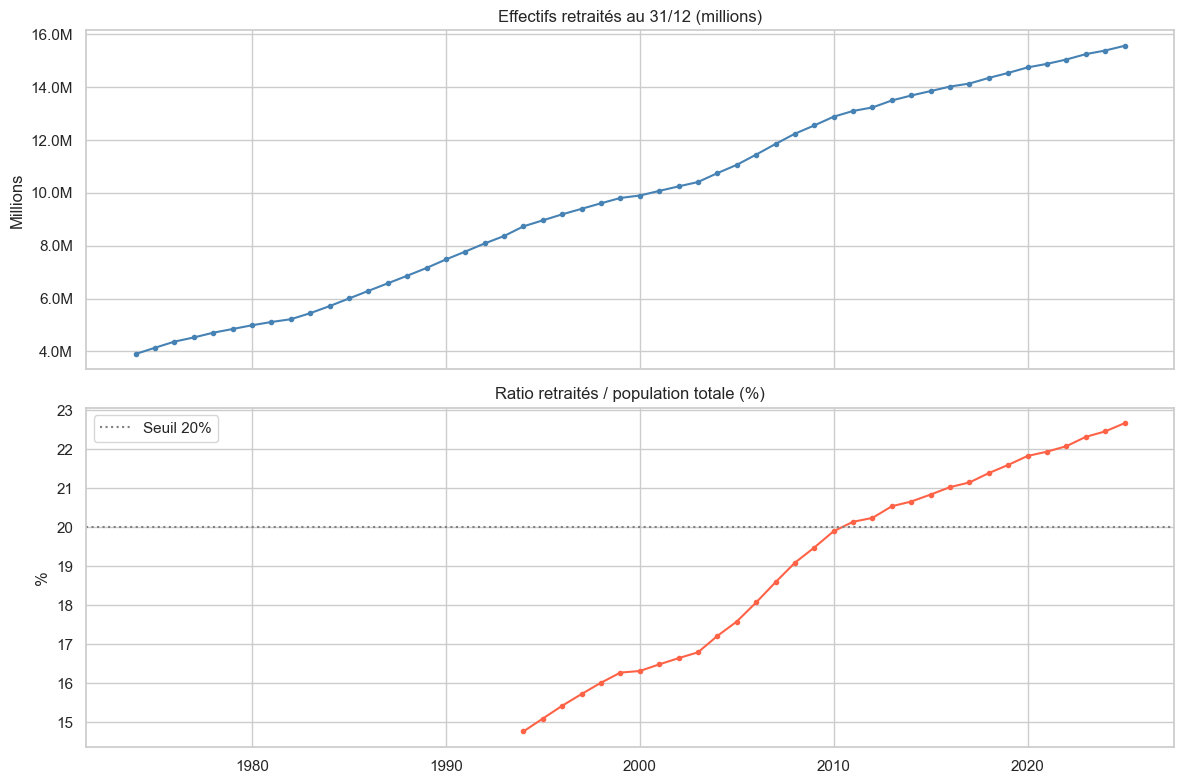

Ratio le plus récent (2025) : 22.7%
Soit 1 retraité pour 4.4 habitants


In [2]:
pop = population.set_index('annee')['population_milliers']

# Aligner sur l'intersection des années
annees_communes = effectifs.index.intersection(pop.index)
ratio = (effectifs.loc[annees_communes] / (pop.loc[annees_communes] * 1000) * 100).round(2)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(effectifs.index, effectifs.values / 1e6, marker='o', markersize=3, color='steelblue')
axes[0].set_title('Effectifs retraités au 31/12 (millions)', fontsize=12)
axes[0].set_ylabel('Millions')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))

axes[1].plot(ratio.index, ratio.values, marker='o', markersize=3, color='tomato')
axes[1].set_title('Ratio retraités / population totale (%)', fontsize=12)
axes[1].set_ylabel('%')
axes[1].axhline(y=20, color='gray', linestyle=':', label='Seuil 20%')
axes[1].legend()

plt.tight_layout()
save_fig(fig, 'ratio_dependance')
plt.show()

print(f'Ratio le plus récent ({int(ratio.index[-1])}) : {ratio.iloc[-1]:.1f}%')
print(f'Soit 1 retraité pour {100/ratio.iloc[-1]:.1f} habitants')

## 2. Pouvoir d'achat réel des pensions — corrigé par l'IPC

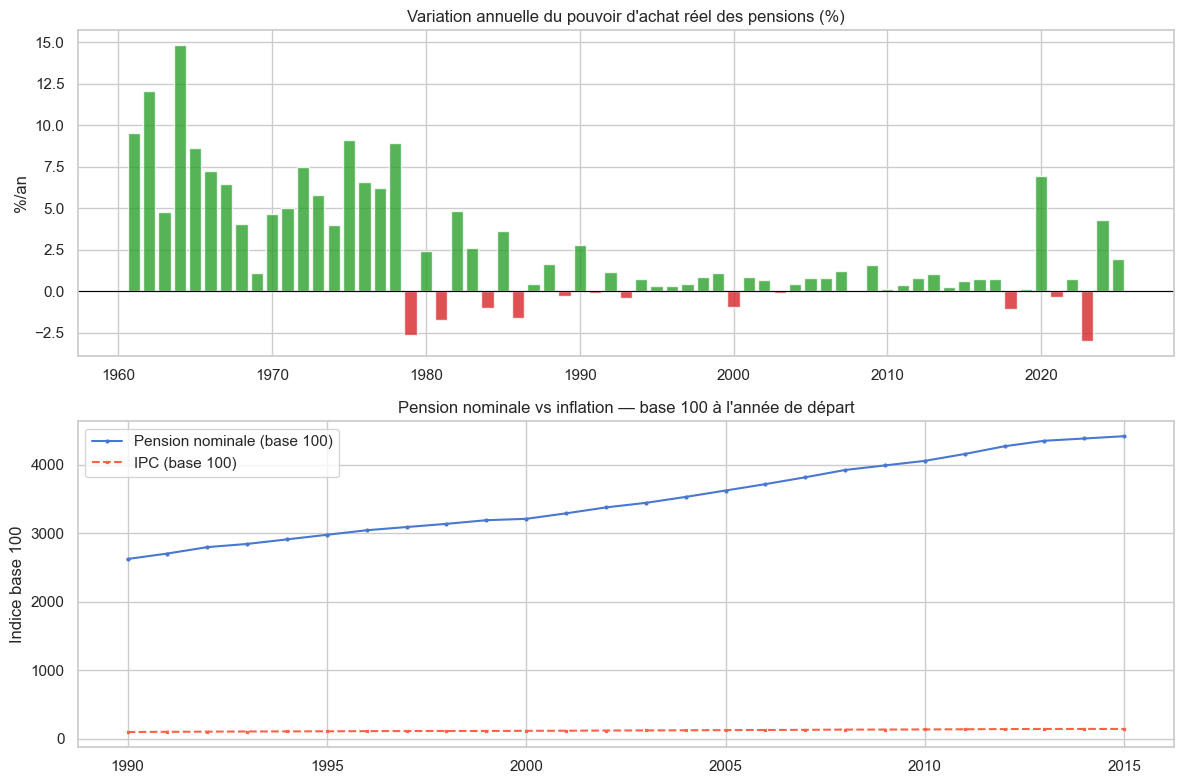

In [3]:
col_nominal = 'montant_mensuel_moyen_au_31_decembre_de_la_retraite_globale_en_euros'
col_reel    = 'montant_equivalent_en_2025_montant_en_euros_corrige_de_l_inflation'

# Variation annuelle du pouvoir d'achat réel
pension_reel = df_montant[col_reel].dropna().sort_index()
var_reel = pension_reel.pct_change() * 100

# IPC : variation annuelle
ipc_s = ipc.set_index('annee')['ipc']
ipc_var = ipc_s.pct_change() * 100

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].bar(var_reel.index, var_reel.values,
            color=['#2ca02c' if v >= 0 else '#d62728' for v in var_reel.fillna(0)],
            alpha=0.8)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Variation annuelle du pouvoir d\'achat réel des pensions (%)', fontsize=12)
axes[0].set_ylabel('%/an')

# Pension nominale vs IPC sur période commune
pension_nom = df_montant[col_nominal].dropna().sort_index()
pension_norm = (pension_nom / pension_nom.iloc[0] * 100)
ann_comm = pension_norm.index.intersection(ipc_s.index)
ipc_norm = (ipc_s.loc[ann_comm] / ipc_s.loc[ann_comm].iloc[0] * 100)

axes[1].plot(pension_norm.loc[ann_comm], label='Pension nominale (base 100)', marker='o', markersize=2)
axes[1].plot(ipc_norm, label='IPC (base 100)', linestyle='--', color='tomato', marker='x', markersize=2)
axes[1].set_title('Pension nominale vs inflation — base 100 à l\'année de départ', fontsize=12)
axes[1].set_ylabel('Indice base 100')
axes[1].legend()

plt.tight_layout()
save_fig(fig, 'pouvoir_achat_retraite')
plt.show()

## 3. Chômage des 50 ans+ et âge de départ à la retraite

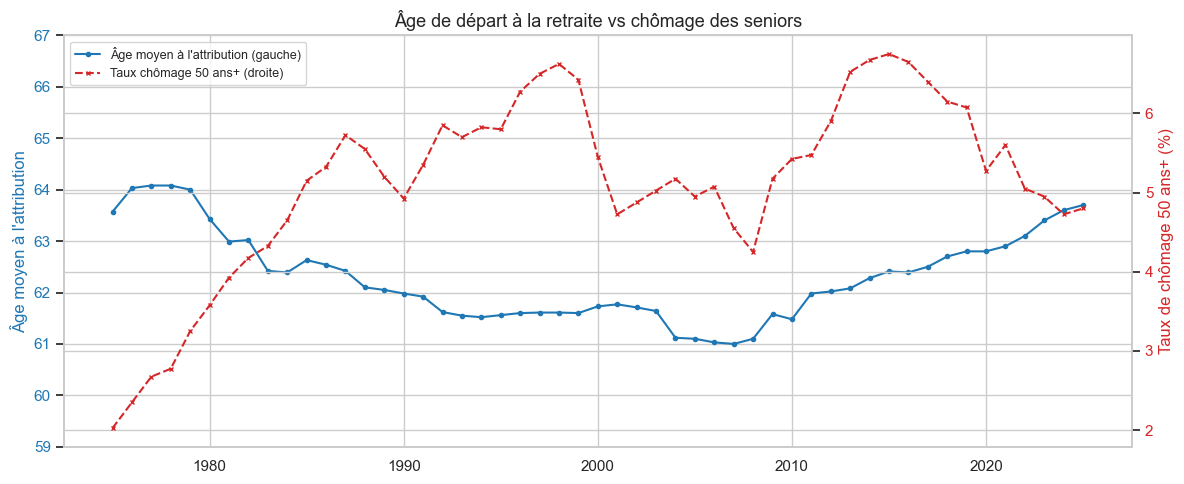

Corrélation âge/chômage seniors : -0.566


In [4]:
cho = chomage_sen.set_index('annee')['chomage_seniors_pct']
age = df_age.set_index('annee')['droits_directs']

# Aligner
ann = cho.index.intersection(age.index)
cho_c = cho.loc[ann]
age_c = age.loc[ann]

fig, ax1 = plt.subplots(figsize=(12, 5))
color1, color2 = '#1f77b4', '#d62728'

ax1.plot(ann, age_c.values, color=color1, marker='o', markersize=3, label="Âge moyen à l'attribution (gauche)")
ax1.set_ylabel("Âge moyen à l'attribution", color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(59, 67)

ax2 = ax1.twinx()
ax2.plot(ann, cho_c.values, color=color2, linestyle='--', marker='x', markersize=3,
         label='Taux chômage 50 ans+ (droite)')
ax2.set_ylabel('Taux de chômage 50 ans+ (%)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
ax1.set_title("Âge de départ à la retraite vs chômage des seniors", fontsize=13)
plt.tight_layout()
save_fig(fig, 'age_depart_chomage_seniors')
plt.show()

# Corrélation
corr = pd.concat([age_c, cho_c], axis=1).corr().iloc[0, 1]
print(f'Corrélation âge/chômage seniors : {corr:.3f}')

## 4. Dynamique démographique — naissances, décès et population

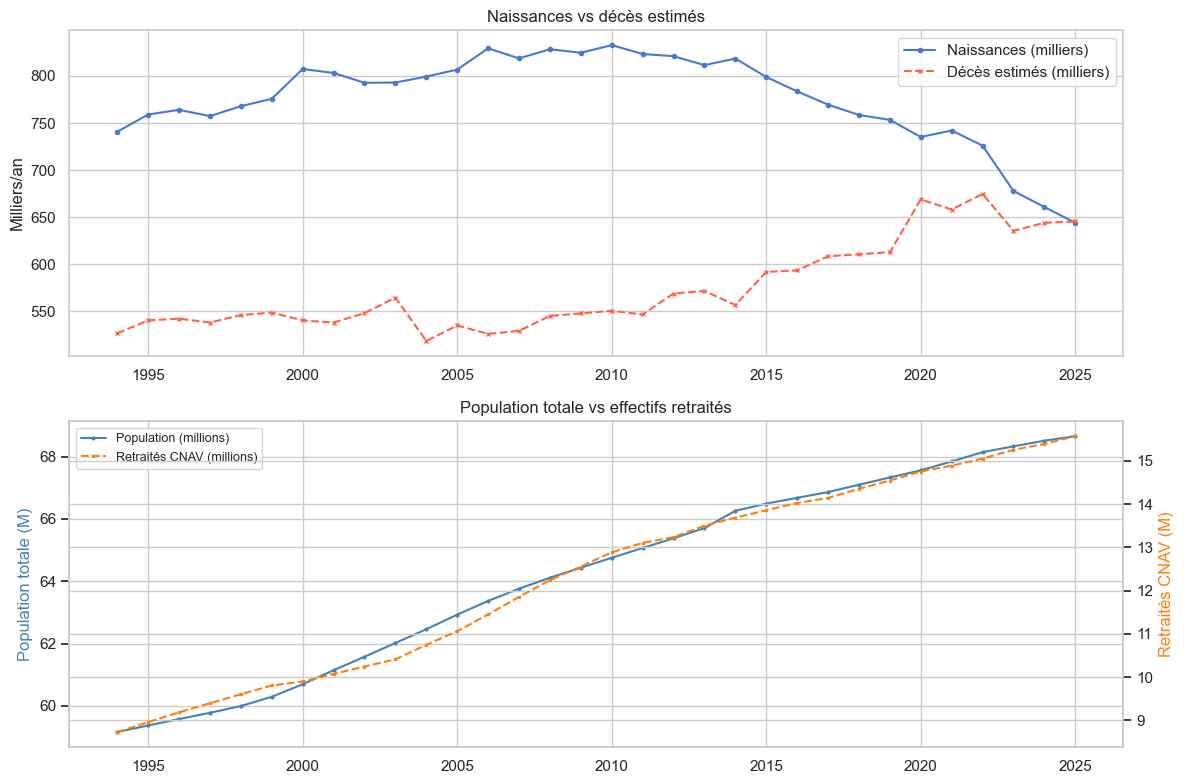

In [5]:
nat = natalite.set_index('annee')['naissances_annuelles']
pop = population.set_index('annee')['population_milliers']
mort = mortalite.set_index('annee')['taux_mortalite']

# Décès estimés en milliers = taux‰ × population_milliers / 1000
ann_deces = mort.index.intersection(pop.index)
deces = (mort.loc[ann_deces] * pop.loc[ann_deces] / 1000).round(1)  # en milliers

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Naissances vs décès (tous deux en milliers/an)
ann_nat_dec = nat.index.intersection(deces.index)
axes[0].plot(ann_nat_dec, nat.loc[ann_nat_dec] / 1000, label='Naissances (milliers)', marker='o', markersize=3)
axes[0].plot(ann_nat_dec, deces.loc[ann_nat_dec], label='Décès estimés (milliers)', linestyle='--',
             marker='x', markersize=3, color='tomato')
axes[0].set_title('Naissances vs décès estimés', fontsize=12)
axes[0].set_ylabel('Milliers/an')
axes[0].legend()

# Population + retraités
ann_pop_ret = effectifs.index.intersection(pop.index)
axes[1].plot(pop.index, pop.values / 1000, label='Population (millions)', color='steelblue', marker='o', markersize=2)
ax2 = axes[1].twinx()
ax2.plot(effectifs.loc[ann_pop_ret].index,
         effectifs.loc[ann_pop_ret].values / 1e6,
         label='Retraités CNAV (millions)', color='#ff7f0e', linestyle='--', marker='x', markersize=2)
axes[1].set_ylabel('Population totale (M)', color='steelblue')
ax2.set_ylabel('Retraités CNAV (M)', color='#ff7f0e')
axes[1].set_title('Population totale vs effectifs retraités', fontsize=12)
lines1, l1 = axes[1].get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, l1 + l2, fontsize=9)

plt.tight_layout()
save_fig(fig, 'demographie_retraites')
plt.show()

## 5. Projection du ratio de dépendance à horizon 20 ans

D:\DEV\retraites-opendata\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
D:\DEV\retraites-opendata\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
D:\DEV\retraites-opendata\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
D:\DEV\retraites-opendata\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is av

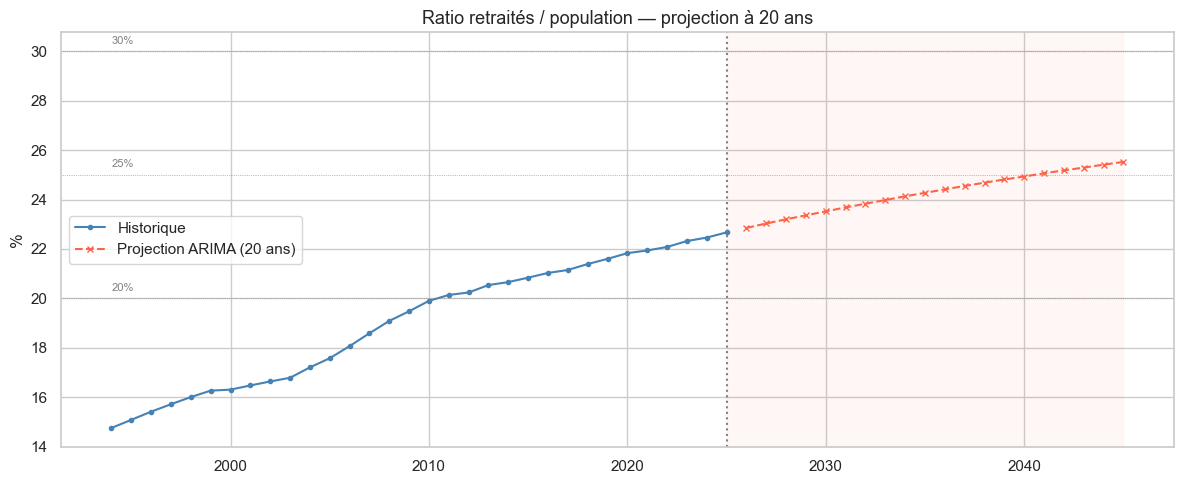

Ratio actuel  (2025) : 22.7%
Ratio projeté (2045)      : 25.5%
Soit 1 retraité pour 3.9 habitants en 2045


In [6]:
from src.models import forecast_arima

HORIZON = 20
ann_base = ratio.index

# Projections ARIMA individuelles
fc_retraites = forecast_arima(effectifs.loc[effectifs.index >= 2000].astype(float), steps=HORIZON)
fc_pop       = forecast_arima(pop.loc[pop.index >= 2000].astype(float), steps=HORIZON)

ratio_proj = (fc_retraites / (fc_pop * 1000) * 100).round(2)

fig, ax = plt.subplots(figsize=(12, 5))

# Historique
ax.plot(ratio.index, ratio.values, color='steelblue', marker='o', markersize=3, label='Historique')
# Projection
ax.plot(ratio_proj.index, ratio_proj.values, color='tomato', linestyle='--',
        marker='x', markersize=4, label=f'Projection ARIMA ({HORIZON} ans)')
# Zone de projection
ax.axvspan(ratio.index[-1], ratio_proj.index[-1], alpha=0.05, color='tomato')
ax.axvline(x=ratio.index[-1], color='gray', linestyle=':')

# Repères
for seuil, label in [(20, '20%'), (25, '25%'), (30, '30%')]:
    ax.axhline(y=seuil, color='gray', linewidth=0.5, linestyle=':')
    ax.text(ratio.index[0], seuil + 0.3, label, fontsize=8, color='gray')

ax.set_title(f'Ratio retraités / population — projection à {HORIZON} ans', fontsize=13)
ax.set_ylabel('%')
ax.legend()
plt.tight_layout()
save_fig(fig, 'projection_ratio_dependance')
plt.show()

dernier_proj = int(ratio_proj.index[-1])
print(f'Ratio actuel  ({int(ratio.index[-1])}) : {ratio.iloc[-1]:.1f}%')
print(f'Ratio projeté ({dernier_proj})      : {ratio_proj.iloc[-1]:.1f}%')
print(f'Soit 1 retraité pour {100/ratio_proj.iloc[-1]:.1f} habitants en {dernier_proj}')

## 6. Synthèse — tableau de bord croisé

In [7]:
# Toutes les données sur une seule période commune
ann_all = sorted(set(ratio.index) & set(cho.index) & set(pension_reel.index))

df_synth = pd.DataFrame({
    'Retraites (M)':          effectifs.loc[ann_all] / 1e6,
    'Ratio depend. (%)':      ratio.loc[ann_all],
    'Pension reelle (E2025)': pension_reel.loc[ann_all],
    'Chomage 50+ (%)':        cho.loc[ann_all],
}, index=ann_all)

print('Tableau de bord croise — dernieres annees disponibles :')
print(df_synth.tail(10).round(2).to_string())

Tableau de bord croise — dernieres annees disponibles :
      Retraites (M)  Ratio depend. (%)  Pension reelle (E2025)  Chomage 50+ (%)
2016          14.02              21.03                     807             6.65
2017          14.14              21.15                     813             6.40
2018          14.35              21.39                     804             6.15
2019          14.54              21.60                     805             6.07
2020          14.75              21.83                     861             5.28
2021          14.88              21.94                     858             5.60
2022          15.05              22.08                     864             5.05
2023          15.25              22.32                     838             4.95
2024          15.39              22.46                     874             4.72
2025          15.57              22.67                     891             4.80
